# Defense vs Tech: Correlation, Volatility, and Hedge Analysis

This notebook studies how major defense contractors behaved relative to the technology sector from **2020-01-01 to 2025-12-31**. The analysis focuses on:

- return behavior and cumulative performance
- rolling volatility and time-varying correlation
- simple hedge ratios from OLS regressions against XLK
- regime-aware interpretation and high-level strategy implications

Assignment alignment:

- dataset collected from Yahoo Finance via `yfinance`
- modular functions for cleaning, analysis, and visualization
- 3+ labeled charts with captions
- modeling/statistical analysis through OLS and hedge diagnostics


In [15]:
# Notebook bootstrap: install anything missing into the current notebook kernel.
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "yfinance": "yfinance",
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages into this notebook kernel:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already installed in this notebook kernel.")

print("Kernel Python:", sys.executable)


All required packages are already installed in this notebook kernel.
Kernel Python: /Users/akshit/Code/IC Quant Project/.venv/bin/python


In [16]:
import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)

# -----------------------------
# Config
# -----------------------------
TICKERS: List[str] = ["LMT", "NOC", "GD", "XLK"]
DEFENSE_TICKERS: List[str] = ["LMT", "NOC", "GD"]
TECH_TICKER = "XLK"
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"
ROLLING_WINDOW = 30
DRAWDOWN_TRIGGER = -0.10
TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE = 0.0

BASE_DIR = Path.cwd()
EXPORT_DIR = BASE_DIR / "outputs"
EXPORT_DIR.mkdir(exist_ok=True)

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Tickers: {TICKERS}")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Rolling window: {ROLLING_WINDOW} trading days")
print(f"Drawdown trigger: {DRAWDOWN_TRIGGER:.0%}")


Tickers: ['LMT', 'NOC', 'GD', 'XLK']
Date range: 2020-01-01 to 2025-12-31
Rolling window: 30 trading days
Drawdown trigger: -10%


## Data Choices

Important design decisions used in this notebook:

- **Returns and risk metrics use `Adj Close`** so stock splits and dividends do not distort investor return measurement.
- **OHLCV fields are still downloaded** for completeness and possible extensions.
- **Missing values are audited first**. Prices are then forward-filled conservatively so small data gaps do not break rolling calculations.
- Because all selected tickers trade in U.S. markets, large alignment issues are unlikely, but the audit table below makes this assumption explicit.


In [17]:
# -----------------------------
# Data loading and preprocessing
# -----------------------------
def fetch_data(tickers: List[str], start: str, end: str) -> pd.DataFrame:
    """Download OHLCV + Adj Close data from Yahoo Finance."""
    df = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="column",
    )
    if df.empty:
        raise ValueError("No data returned. Check ticker symbols or internet connectivity.")
    return df.sort_index()


def extract_field(raw_df: pd.DataFrame, field: str) -> pd.DataFrame:
    """Extract one field across all tickers from yfinance's column structure."""
    if isinstance(raw_df.columns, pd.MultiIndex):
        if field in raw_df.columns.get_level_values(0):
            extracted = raw_df[field].copy()
        else:
            extracted = raw_df.xs(field, axis=1, level=-1).copy()
    else:
        extracted = raw_df[[field]].copy()

    if isinstance(extracted, pd.Series):
        extracted = extracted.to_frame(name=TICKERS[0])

    return extracted.sort_index()


def audit_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Summarize missingness before cleaning."""
    audit = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "first_valid": df.apply(pd.Series.first_valid_index),
        "last_valid": df.apply(pd.Series.last_valid_index),
    })
    return audit.sort_values("missing_count", ascending=False)


def clean_price_data(prices: pd.DataFrame) -> pd.DataFrame:
    """Forward-fill small gaps after documenting them."""
    cleaned = prices.sort_index().copy()
    cleaned = cleaned.ffill()
    cleaned = cleaned.dropna(how="all")
    return cleaned


def calculate_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Compute simple daily returns."""
    returns = prices.pct_change().dropna(how="all")
    return returns.dropna()


def normalize_prices(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.div(prices.iloc[0]).mul(100)


raw_data = fetch_data(TICKERS, START_DATE, END_DATE)
adj_close_raw = extract_field(raw_data, "Adj Close")
close_raw = extract_field(raw_data, "Close")
volume_raw = extract_field(raw_data, "Volume")

missing_audit = audit_missing_values(adj_close_raw)
adj_close = clean_price_data(adj_close_raw)
returns = calculate_returns(adj_close)
normalized_prices = normalize_prices(adj_close)

display(missing_audit)
display(adj_close.tail())
display(returns.tail())


,missing_count,missing_pct,first_valid,last_valid
Ticker,,,,
GD,0,0.0000,2020-01-02,2025-12-30
LMT,0,0.0000,2020-01-02,2025-12-30
NOC,0,0.0000,2020-01-02,2025-12-30
XLK,0,0.0000,2020-01-02,2025-12-30


Ticker,GD,LMT,NOC,XLK
Date,,,,
2025-12-23,340.8578,480.0202,578.2081,145.7688
2025-12-24,342.3944,483.2034,580.4908,146.1183
2025-12-26,339.2321,480.4977,575.5267,146.3480
2025-12-29,337.5270,486.3071,575.9354,145.6889
2025-12-30,336.5258,485.4417,572.7357,145.2294


Ticker,GD,LMT,NOC,XLK
Date,,,,
2025-12-23,-0.0039,-0.0021,-0.0079,0.0054
2025-12-24,0.0045,0.0066,0.0039,0.0024
2025-12-26,-0.0092,-0.0056,-0.0086,0.0016
2025-12-29,-0.0050,0.0121,0.0007,-0.0045
2025-12-30,-0.0030,-0.0018,-0.0056,-0.0032


## Statistical Functions

These helpers keep the notebook modular and make it easy to rerun the same workflow with different tickers, windows, or time periods.


In [18]:
# -----------------------------
# Statistics and modeling
# -----------------------------
def annualize_return(daily_returns: pd.Series) -> float:
    compounded = (1 + daily_returns).prod()
    periods = daily_returns.shape[0]
    return compounded ** (TRADING_DAYS_PER_YEAR / periods) - 1 if periods > 0 else np.nan


def annualize_volatility(daily_returns: pd.Series) -> float:
    return daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)


def calculate_max_drawdown(daily_returns: pd.Series) -> float:
    cumulative = (1 + daily_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative.div(running_max) - 1
    return drawdown.min()


def get_summary_stats(returns_df: pd.DataFrame) -> pd.DataFrame:
    rows = {}
    for ticker in returns_df.columns:
        series = returns_df[ticker].dropna()
        ann_return = annualize_return(series)
        ann_vol = annualize_volatility(series)
        sharpe = (ann_return - RISK_FREE_RATE) / ann_vol if ann_vol else np.nan
        rows[ticker] = {
            "annual_return": ann_return,
            "annual_volatility": ann_vol,
            "sharpe_ratio": sharpe,
            "max_drawdown": calculate_max_drawdown(series),
            "average_daily_return": series.mean(),
            "daily_volatility": series.std(),
        }
    return pd.DataFrame(rows).T.sort_values("annual_return", ascending=False)


def get_rolling_volatility(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    return returns_df.rolling(window).std() * np.sqrt(TRADING_DAYS_PER_YEAR)


def get_correlation_matrix(returns_df: pd.DataFrame) -> pd.DataFrame:
    return returns_df.corr()


def get_rolling_correlation(returns_df: pd.DataFrame, base_ticker: str, window: int) -> pd.DataFrame:
    rolling_corr = {}
    for ticker in returns_df.columns:
        if ticker == base_ticker:
            continue
        rolling_corr[f"{ticker}_vs_{base_ticker}"] = returns_df[ticker].rolling(window).corr(returns_df[base_ticker])
    return pd.DataFrame(rolling_corr)


def get_rolling_beta(returns_df: pd.DataFrame, base_ticker: str, window: int) -> pd.DataFrame:
    rolling_beta = {}
    base_variance = returns_df[base_ticker].rolling(window).var()
    for ticker in returns_df.columns:
        if ticker == base_ticker:
            continue
        covariance = returns_df[ticker].rolling(window).cov(returns_df[base_ticker])
        rolling_beta[f"{ticker}_beta_to_{base_ticker}"] = covariance.div(base_variance)
    return pd.DataFrame(rolling_beta)


def calculate_drawdown(returns_df: pd.DataFrame) -> pd.DataFrame:
    cumulative = (1 + returns_df).cumprod()
    running_max = cumulative.cummax()
    return cumulative.div(running_max) - 1


def build_regime_table(returns_df: pd.DataFrame, market_ticker: str, window: int) -> pd.DataFrame:
    market_vol = returns_df[market_ticker].rolling(window).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    non_null_vol = market_vol.dropna()
    if non_null_vol.empty:
        return pd.DataFrame()

    quantile_codes = pd.qcut(non_null_vol, q=3, labels=False, duplicates="drop")
    label_map = {0: "Low Vol", 1: "Medium Vol", 2: "High Vol"}
    vol_state = quantile_codes.map(label_map).rename("vol_regime")
    joined = returns_df.join(vol_state, how="inner")
    grouped = joined.groupby("vol_regime").agg(["mean", "std"])
    return grouped


def run_ols_regression(y: pd.Series, x: pd.Series):
    aligned = pd.concat([y, x], axis=1).dropna()
    aligned.columns = ["y", "x"]
    X = sm.add_constant(aligned["x"])
    model = sm.OLS(aligned["y"], X).fit()
    predictions = model.predict(X)
    residuals = aligned["y"] - predictions
    metrics = {
        "hedge_ratio": model.params["x"],
        "alpha": model.params["const"],
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "rmse": np.sqrt(np.mean(residuals**2)),
        "mae": np.mean(np.abs(residuals)),
        "aic": model.aic,
        "bic": model.bic,
    }
    return model, metrics, residuals


def calculate_spread(defense_returns: pd.Series, tech_returns: pd.Series, hedge_ratio: float) -> pd.Series:
    aligned = pd.concat([defense_returns, tech_returns], axis=1).dropna()
    aligned.columns = ["defense", "tech"]
    return aligned["defense"] - hedge_ratio * aligned["tech"]


def backtest_regime_strategy(
    returns_df: pd.DataFrame,
    rolling_vol_df: pd.DataFrame,
    market_ticker: str,
    window: int,
    lag_signals: bool = True,
) -> Tuple[pd.Series, pd.DataFrame]:
    market_vol = returns_df[market_ticker].rolling(window).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    non_null_vol = market_vol.dropna()
    if non_null_vol.empty:
        return pd.Series(dtype=float), pd.DataFrame()

    quantile_codes = pd.qcut(non_null_vol, q=3, labels=False, duplicates="drop")
    label_map = {0: "Low Vol", 1: "Medium Vol", 2: "High Vol"}
    regime_series = quantile_codes.map(label_map).rename("regime")
    trailing_strength_df = returns_df[DEFENSE_TICKERS].rolling(window).mean()

    strategy_returns = []
    decision_log = []

    available_dates = list(regime_series.index)
    max_index = len(available_dates) - 1 if lag_signals else len(available_dates)
    for idx in range(max_index):
        signal_date = available_dates[idx]
        trade_date = available_dates[idx + 1] if lag_signals else available_dates[idx]
        regime = regime_series.loc[signal_date]
        trade_returns = returns_df.loc[trade_date]
        rolling_row = rolling_vol_df.loc[signal_date, DEFENSE_TICKERS]

        if regime == "Low Vol":
            chosen_asset = market_ticker
        elif regime == "High Vol":
            chosen_asset = rolling_row.dropna().idxmin() if not rolling_row.dropna().empty else market_ticker
        else:
            trailing_strength = trailing_strength_df.loc[signal_date].dropna()
            chosen_asset = trailing_strength.idxmax() if not trailing_strength.empty else market_ticker

        strategy_returns.append(pd.Series({"date": trade_date, "strategy_return": trade_returns[chosen_asset]}))
        decision_log.append(pd.Series({
            "date": trade_date,
            "signal_date": signal_date,
            "regime": regime,
            "chosen_asset": chosen_asset,
        }))

    strategy_series = pd.DataFrame(strategy_returns).set_index("date")["strategy_return"]
    decisions_df = pd.DataFrame(decision_log).set_index("date")
    benchmark = returns_df[market_ticker].rename("benchmark_return")
    combined = pd.concat([strategy_series, benchmark, decisions_df], axis=1).dropna(subset=["strategy_return", "benchmark_return"])
    return combined["strategy_return"], combined


def backtest_drawdown_beta_strategy(
    returns_df: pd.DataFrame,
    drawdown_data: pd.DataFrame,
    rolling_beta_df: pd.DataFrame,
    market_ticker: str,
    drawdown_trigger: float,
) -> Tuple[pd.Series, pd.DataFrame]:
    strategy_returns = []
    decision_log = []

    available_dates = list(rolling_beta_df.dropna(how="all").index)
    for idx in range(len(available_dates) - 1):
        signal_date = available_dates[idx]
        trade_date = available_dates[idx + 1]
        xlk_drawdown = drawdown_data.loc[signal_date, market_ticker]
        beta_row = rolling_beta_df.loc[signal_date].dropna()

        if xlk_drawdown <= drawdown_trigger and not beta_row.empty:
            chosen_asset = beta_row.idxmin().replace(f"_beta_to_{market_ticker}", "")
            signal_state = "Defense Switch"
        else:
            chosen_asset = market_ticker
            signal_state = "Stay XLK"

        strategy_returns.append(pd.Series({"date": trade_date, "strategy_return": returns_df.loc[trade_date, chosen_asset]}))
        decision_log.append(pd.Series({
            "date": trade_date,
            "signal_date": signal_date,
            "xlk_drawdown": xlk_drawdown,
            "signal_state": signal_state,
            "chosen_asset": chosen_asset,
        }))

    strategy_series = pd.DataFrame(strategy_returns).set_index("date")["strategy_return"]
    decisions_df = pd.DataFrame(decision_log).set_index("date")
    benchmark = returns_df[market_ticker].rename("benchmark_return")
    combined = pd.concat([strategy_series, benchmark, decisions_df], axis=1).dropna(subset=["strategy_return", "benchmark_return"])
    return combined["strategy_return"], combined


summary_stats = get_summary_stats(returns)
rolling_vol = get_rolling_volatility(returns, ROLLING_WINDOW)
correlation_matrix = get_correlation_matrix(returns)
rolling_corr_vs_xlk = get_rolling_correlation(returns, TECH_TICKER, ROLLING_WINDOW)
rolling_beta_vs_xlk = get_rolling_beta(returns, TECH_TICKER, ROLLING_WINDOW)
drawdown_df = calculate_drawdown(returns)
regime_table = build_regime_table(returns, TECH_TICKER, ROLLING_WINDOW)

hedge_models: Dict[str, object] = {}
hedge_metrics_rows: Dict[str, Dict[str, float]] = {}
hedge_spreads: Dict[str, pd.Series] = {}

for ticker in DEFENSE_TICKERS:
    model, metrics, residuals = run_ols_regression(returns[ticker], returns[TECH_TICKER])
    hedge_models[ticker] = model
    hedge_metrics_rows[ticker] = metrics
    hedge_spreads[ticker] = calculate_spread(returns[ticker], returns[TECH_TICKER], metrics["hedge_ratio"])

hedge_metrics = pd.DataFrame(hedge_metrics_rows).T.sort_values("r_squared", ascending=False)
biased_strategy_returns, biased_strategy_log = backtest_regime_strategy(returns, rolling_vol, TECH_TICKER, ROLLING_WINDOW, lag_signals=False)
strategy_returns, strategy_log = backtest_regime_strategy(returns, rolling_vol, TECH_TICKER, ROLLING_WINDOW, lag_signals=True)
drawdown_strategy_returns, drawdown_strategy_log = backtest_drawdown_beta_strategy(
    returns,
    drawdown_df,
    rolling_beta_vs_xlk,
    TECH_TICKER,
    DRAWDOWN_TRIGGER,
)
biased_strategy_comparison = pd.DataFrame({
    "Biased Regime Strategy": (1 + biased_strategy_returns).cumprod(),
    TECH_TICKER: (1 + returns[TECH_TICKER].loc[biased_strategy_returns.index]).cumprod(),
})
strategy_comparison = pd.DataFrame({
    "Regime Strategy": (1 + strategy_returns).cumprod(),
    TECH_TICKER: (1 + returns[TECH_TICKER].loc[strategy_returns.index]).cumprod(),
})
drawdown_strategy_comparison = pd.DataFrame({
    "Drawdown Beta Strategy": (1 + drawdown_strategy_returns).cumprod(),
    TECH_TICKER: (1 + returns[TECH_TICKER].loc[drawdown_strategy_returns.index]).cumprod(),
})
strategy_summary = pd.DataFrame({
    "annual_return": {
        "Regime Strategy": annualize_return(strategy_returns),
        TECH_TICKER: annualize_return(returns[TECH_TICKER].loc[strategy_returns.index]),
    },
    "annual_volatility": {
        "Regime Strategy": annualize_volatility(strategy_returns),
        TECH_TICKER: annualize_volatility(returns[TECH_TICKER].loc[strategy_returns.index]),
    },
    "max_drawdown": {
        "Regime Strategy": calculate_max_drawdown(strategy_returns),
        TECH_TICKER: calculate_max_drawdown(returns[TECH_TICKER].loc[strategy_returns.index]),
    },
})
drawdown_strategy_summary = pd.DataFrame({
    "annual_return": {
        "Drawdown Beta Strategy": annualize_return(drawdown_strategy_returns),
        TECH_TICKER: annualize_return(returns[TECH_TICKER].loc[drawdown_strategy_returns.index]),
    },
    "annual_volatility": {
        "Drawdown Beta Strategy": annualize_volatility(drawdown_strategy_returns),
        TECH_TICKER: annualize_volatility(returns[TECH_TICKER].loc[drawdown_strategy_returns.index]),
    },
    "max_drawdown": {
        "Drawdown Beta Strategy": calculate_max_drawdown(drawdown_strategy_returns),
        TECH_TICKER: calculate_max_drawdown(returns[TECH_TICKER].loc[drawdown_strategy_returns.index]),
    },
})

display(summary_stats)
display(correlation_matrix)
display(hedge_metrics)
display(regime_table)
display(strategy_summary)
display(drawdown_strategy_summary)


,annual_return,annual_volatility,sharpe_ratio,max_drawdown,average_daily_return,daily_volatility
XLK,0.2198,0.2790,0.7879,-0.3356,0.0009,0.0176
GD,0.1402,0.2444,0.5734,-0.4373,0.0006,0.0154
NOC,0.1017,0.2747,0.3701,-0.2963,0.0005,0.0173
LMT,0.0627,0.2612,0.2399,-0.3667,0.0004,0.0165


Ticker,GD,LMT,NOC,XLK
Ticker,,,,
GD,1.0000,0.6642,0.6359,0.4507
LMT,0.6642,1.0000,0.7233,0.2874
NOC,0.6359,0.7233,1.0000,0.2321
XLK,0.4507,0.2874,0.2321,1.0000


,hedge_ratio,alpha,r_squared,adj_r_squared,rmse,mae,aic,bic
GD,0.3949,0.0003,0.2031,0.2026,0.0137,0.0097,"-8,635.6757","-8,625.0413"
LMT,0.2691,0.0001,0.0826,0.0820,0.0158,0.0103,"-8,223.9344","-8,213.3000"
NOC,0.2285,0.0003,0.0538,0.0532,0.0168,0.0114,"-8,025.9557","-8,015.3212"


GD            LMT           NOC           XLK       
             mean    std    mean    std   mean    std   mean    std
vol_regime                                                         
High Vol   0.0006 0.0209  0.0013 0.0221 0.0011 0.0231 0.0003 0.0253
Low Vol    0.0008 0.0112 -0.0004 0.0127 0.0003 0.0133 0.0013 0.0103
Medium Vol 0.0004 0.0126  0.0001 0.0130 0.0001 0.0140 0.0011 0.0138

,annual_return,annual_volatility,max_drawdown
Regime Strategy,0.1346,0.2574,-0.4213
XLK,0.2065,0.2806,-0.3356


,annual_return,annual_volatility,max_drawdown
Drawdown Beta Strategy,0.1147,0.2568,-0.3975
XLK,0.2065,0.2806,-0.3356


## Visualization Functions

Each chart is independent and can be exported or reused in the report and presentation.


In [19]:
# -----------------------------
# Visualization helpers
# -----------------------------
def plot_price_evolution(prices: pd.DataFrame, normalize: bool = True):
    plot_df = normalize_prices(prices) if normalize else prices.copy()
    title = "Normalized Price Performance (Base = 100)" if normalize else "Adjusted Close Price Levels"
    ax = plot_df.plot(linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Indexed Value" if normalize else "Adjusted Close Price")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


def plot_rolling_volatility(rolling_vol_df: pd.DataFrame, window: int):
    ax = rolling_vol_df.plot(linewidth=2)
    ax.set_title(f"{window}-Day Rolling Annualized Volatility")
    ax.set_xlabel("Date")
    ax.set_ylabel("Annualized Volatility")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


def plot_correlation_matrix(corr_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr_df, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlation Matrix of Daily Returns")
    plt.tight_layout()
    return ax


def plot_rolling_correlation(rolling_corr_df: pd.DataFrame, window: int):
    ax = rolling_corr_df.plot(linewidth=2)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{window}-Day Rolling Correlation vs {TECH_TICKER}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Correlation")
    ax.legend(title="Pair")
    plt.tight_layout()
    return ax


def plot_rolling_beta(rolling_beta_df: pd.DataFrame, window: int):
    ax = rolling_beta_df.plot(linewidth=2)
    ax.axhline(1, color="black", linestyle="--", linewidth=1, label="Beta = 1")
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{window}-Day Rolling Beta vs {TECH_TICKER}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Beta")
    ax.legend(title="Pair")
    plt.tight_layout()
    return ax


def plot_returns_distribution(returns_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
    axes = axes.flatten()
    for ax, ticker in zip(axes, returns_df.columns):
        sns.histplot(returns_df[ticker], kde=True, bins=40, ax=ax, color="#2a6f97")
        ax.set_title(f"Return Distribution: {ticker}")
        ax.set_xlabel("Daily Return")
    plt.tight_layout()
    return axes


def plot_hedged_spreads(spread_dict: Dict[str, pd.Series]):
    spread_df = pd.DataFrame(spread_dict)
    cumulative_spread = spread_df.cumsum()
    ax = cumulative_spread.plot(linewidth=2)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Cumulative Hedged Return Spreads vs XLK")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Spread Return")
    ax.legend(title="Defense vs XLK")
    plt.tight_layout()
    return ax


def plot_drawdowns(drawdown_data: pd.DataFrame):
    ax = drawdown_data.plot(linewidth=2)
    ax.set_title("Rolling Drawdown Paths")
    ax.set_xlabel("Date")
    ax.set_ylabel("Drawdown")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


def plot_strategy_comparison(strategy_df: pd.DataFrame):
    indexed = strategy_df.div(strategy_df.iloc[0]).mul(100)
    ax = indexed.plot(linewidth=2)
    ax.set_title("Strategy vs XLK (Base = 100)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Indexed Value")
    ax.legend(title="Series")
    plt.tight_layout()
    return ax


## Regime Concepts

- **Regime** means a market state or environment, not a government or political term here. In this notebook, regimes are defined by whether `XLK`'s rolling volatility is relatively low, medium, or high.
- **High-vol regime vs low-vol regime** means periods where the recent 30-day volatility of `XLK` is unusually high or unusually low relative to the rest of the sample.
- **Rolling beta vs XLK** asks: over the last 30 trading days, how much did a defense stock tend to move when `XLK` moved?
- A rolling beta near `1.0` means the stock moved about one-for-one with `XLK` over that window.
- A rolling beta below `1.0` means the stock was less sensitive than `XLK` to tech-sector moves.
- A rolling beta near `0` means very little relationship over that window.
- A negative rolling beta means the stock moved opposite to `XLK` over that window.


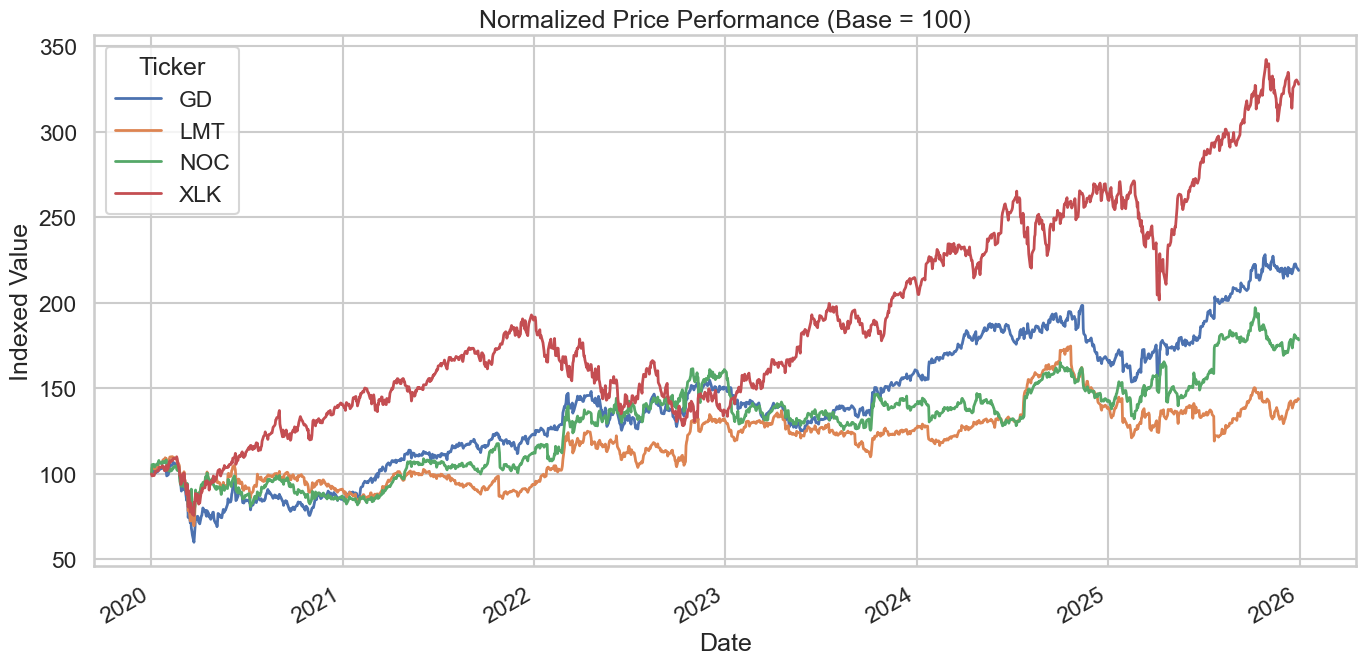

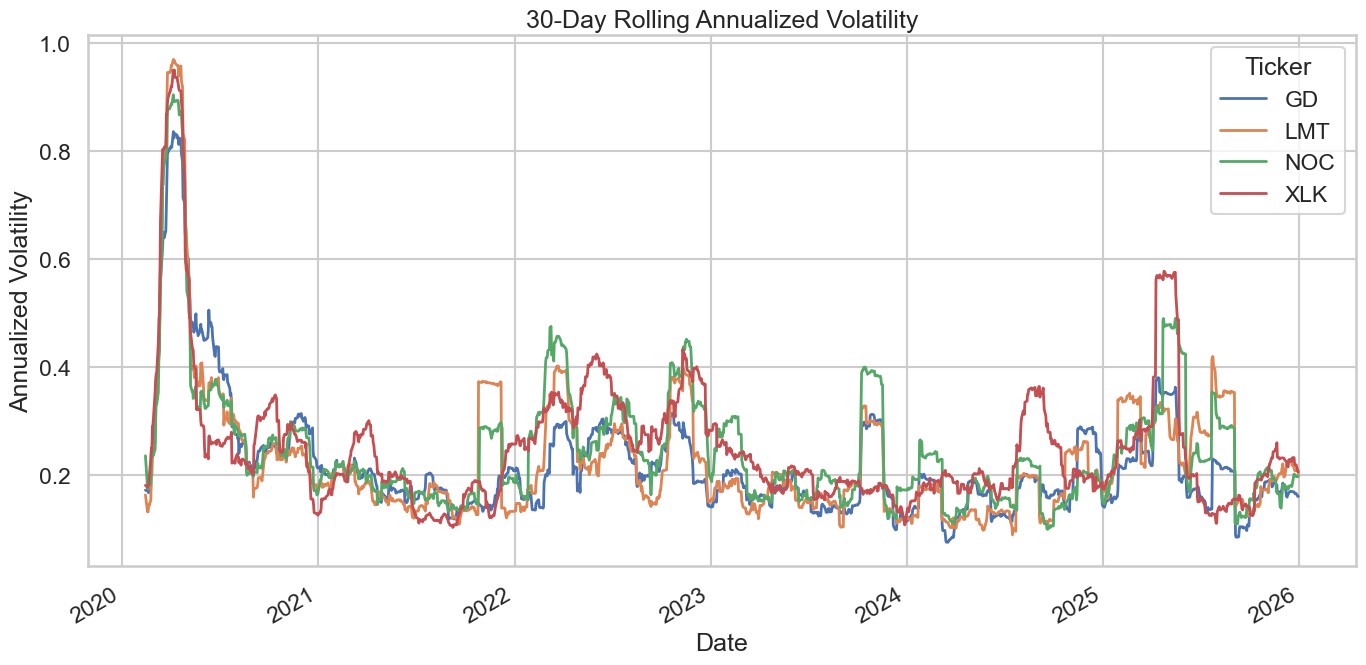

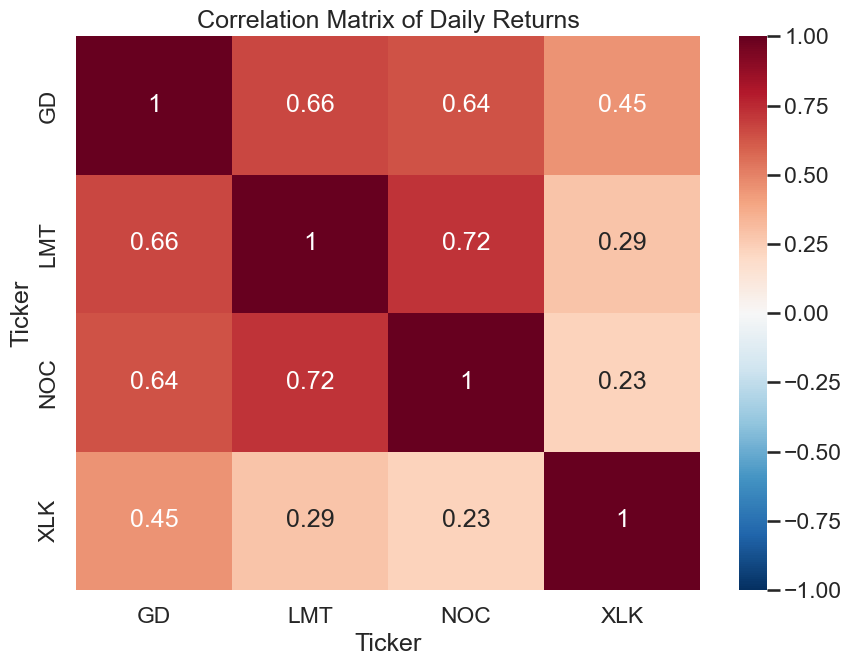

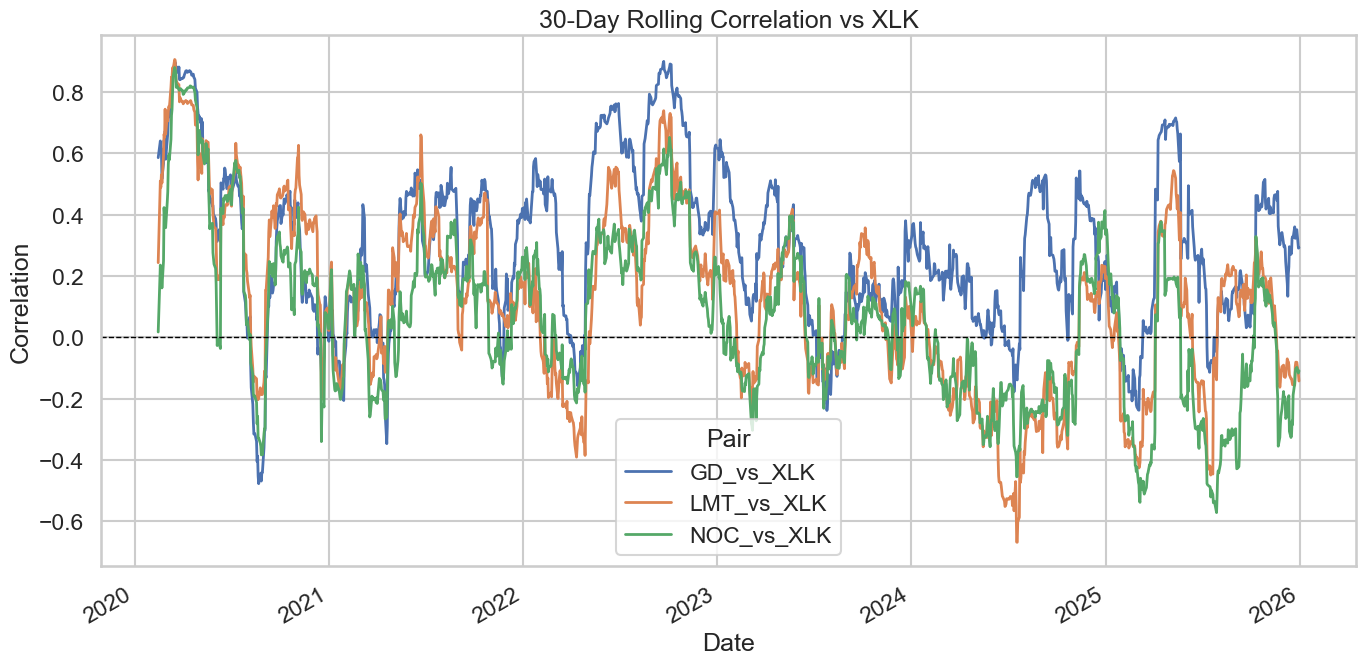

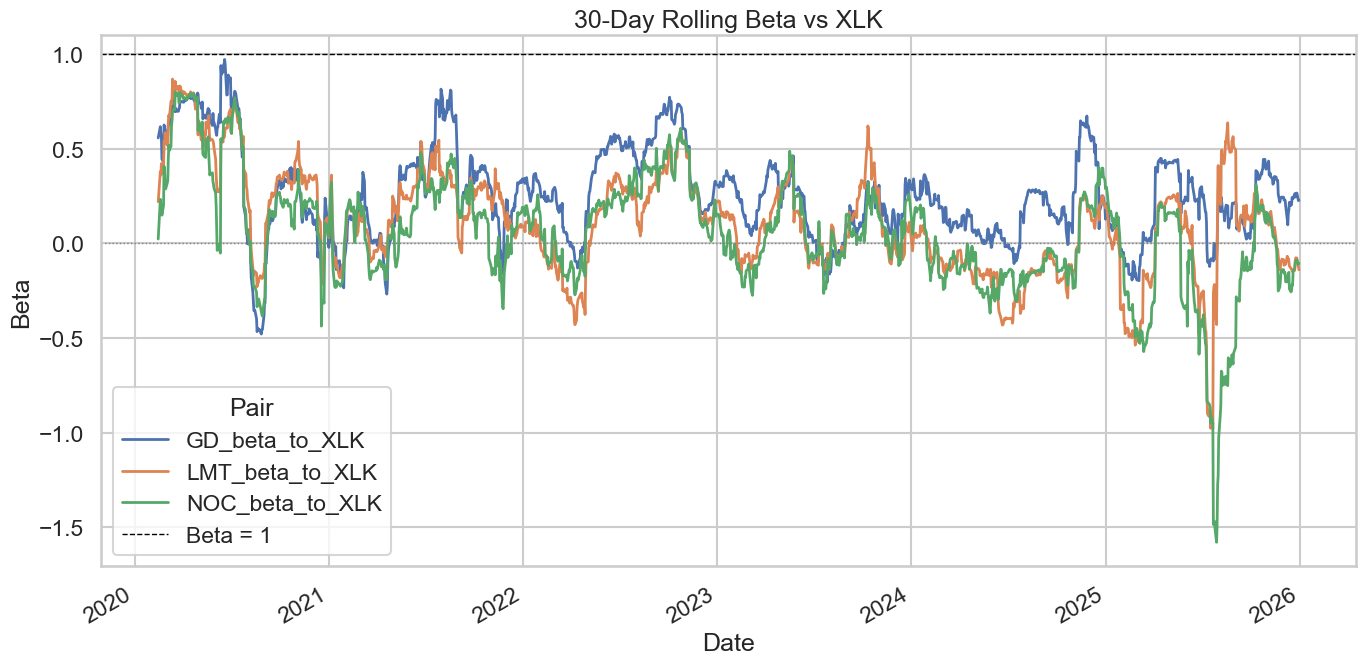

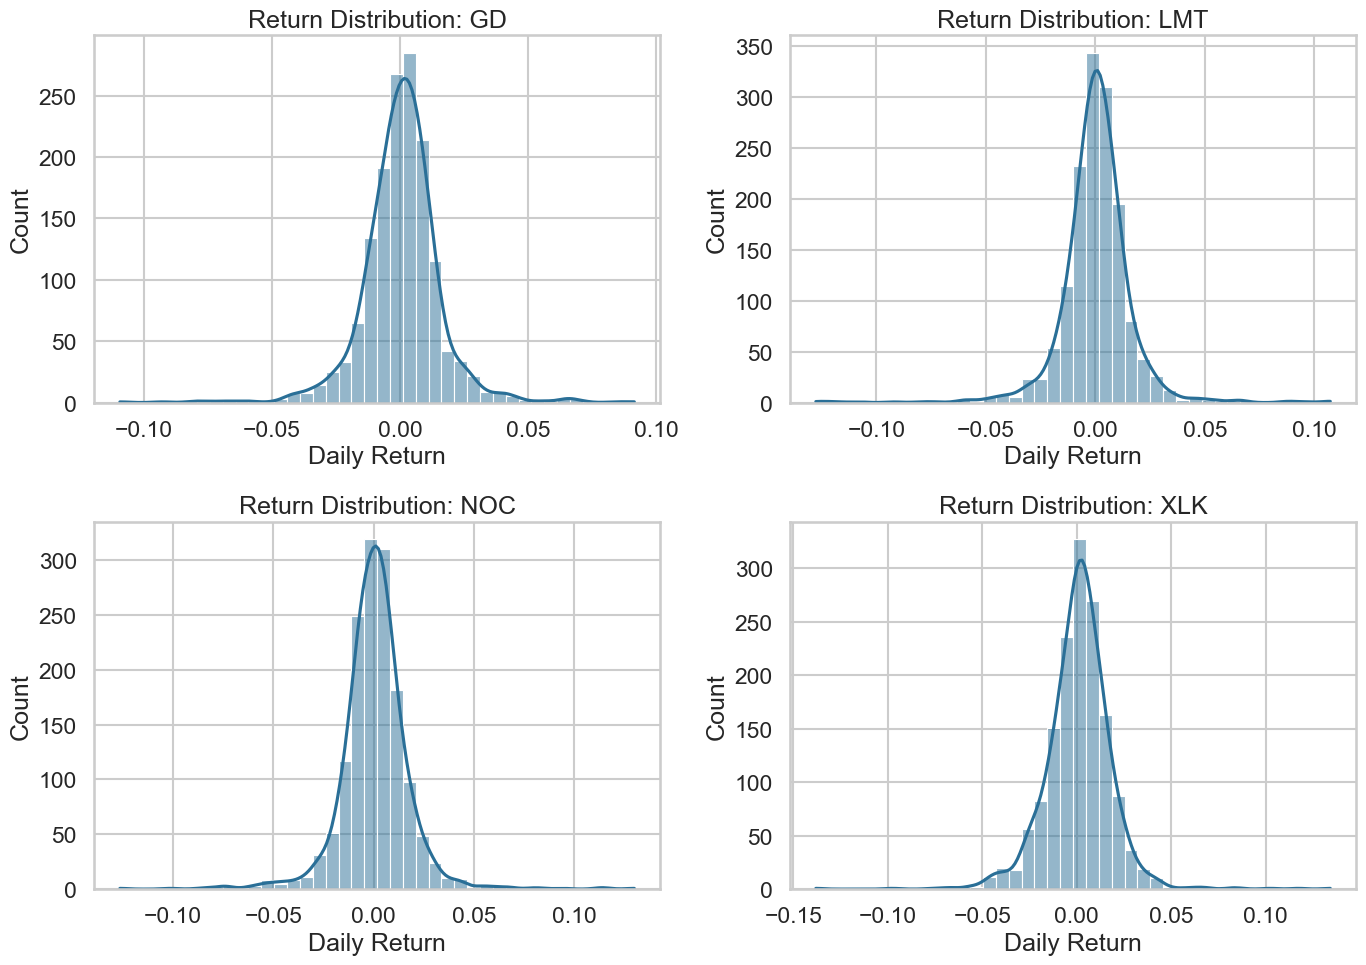

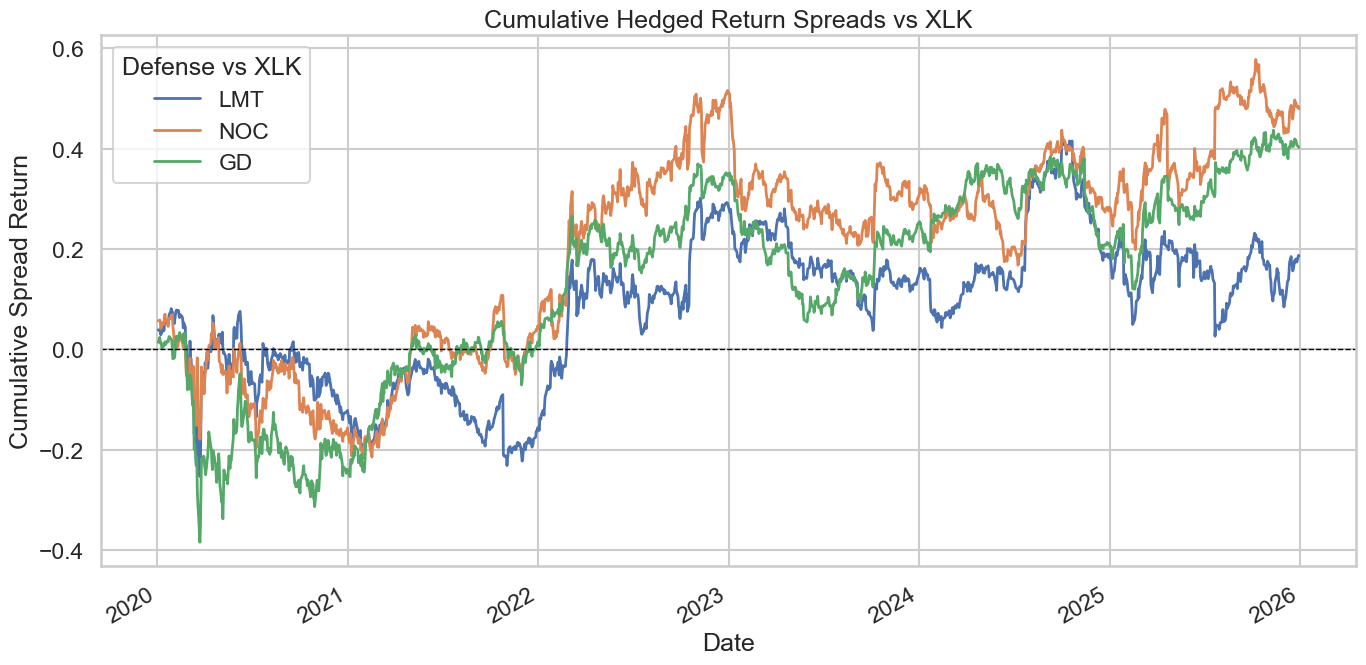

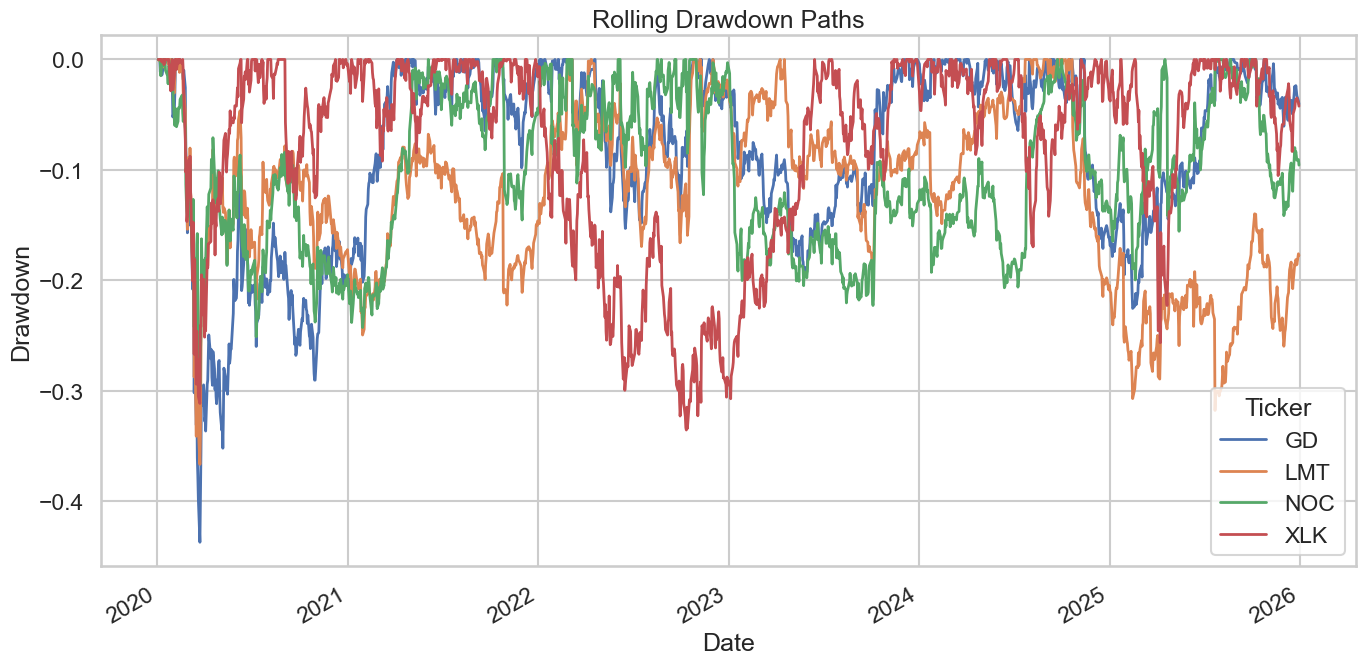

In [20]:
# -----------------------------
# Section 1: Core correlation and risk analysis
# -----------------------------
plot_price_evolution(adj_close, normalize=True)
plt.show()

plot_rolling_volatility(rolling_vol, ROLLING_WINDOW)
plt.show()

plot_correlation_matrix(correlation_matrix)
plt.show()

plot_rolling_correlation(rolling_corr_vs_xlk, ROLLING_WINDOW)
plt.show()

plot_rolling_beta(rolling_beta_vs_xlk, ROLLING_WINDOW)
plt.show()

plot_returns_distribution(returns)
plt.show()

plot_hedged_spreads(hedge_spreads)
plt.show()

plot_drawdowns(drawdown_df)
plt.show()


## Section 2: Regime Strategy Test

This section documents two versions of the regime strategy:

- the original same-day version, which produced a false positive because it leaked future information into the trade decision
- the corrected one-day-lagged version, which is the only version that should be interpreted seriously


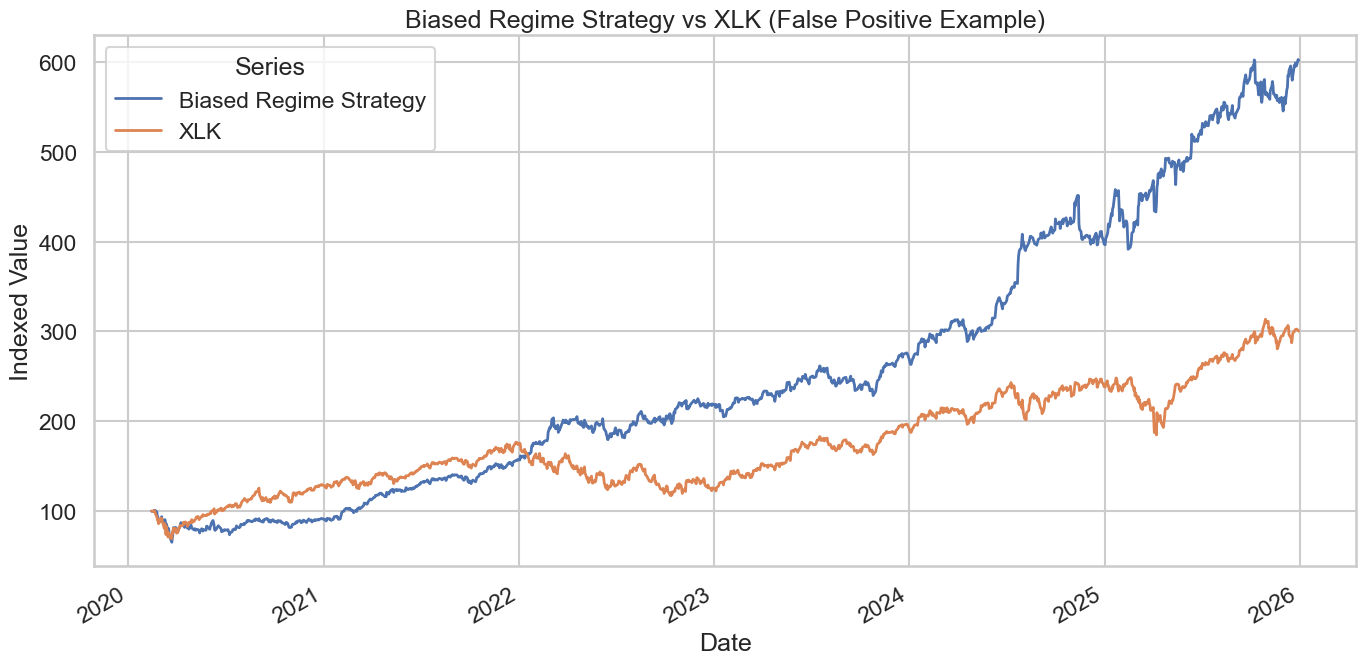

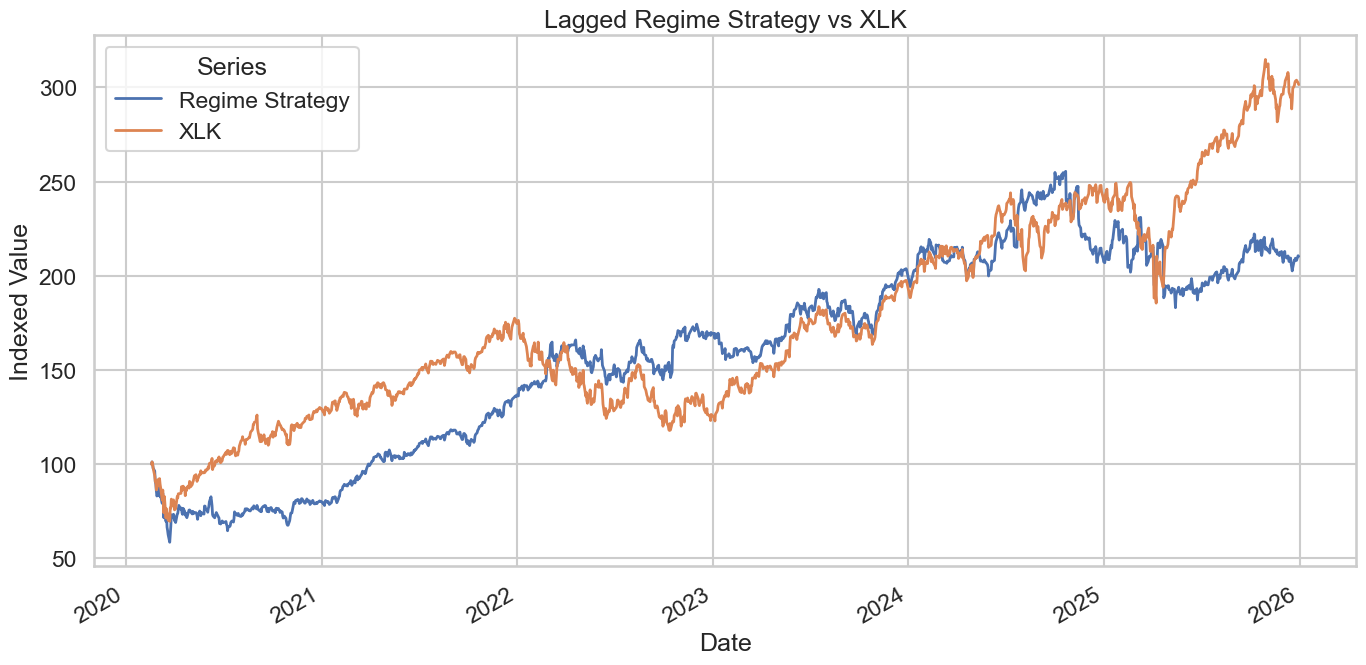

,annual_return,annual_volatility,max_drawdown
Regime Strategy,0.1346,0.2574,-0.4213
XLK,0.2065,0.2806,-0.3356


,strategy_return,benchmark_return,signal_date,regime,chosen_asset
2020-02-18,-0.0037,-0.0037,2020-02-14,Low Vol,XLK
2020-02-19,0.0119,0.0119,2020-02-18,Low Vol,XLK
2020-02-20,-0.0104,-0.0104,2020-02-19,Low Vol,XLK
2020-02-21,-0.0224,-0.0224,2020-02-20,Low Vol,XLK
2020-02-24,-0.0159,-0.0413,2020-02-21,Medium Vol,GD
2020-02-25,-0.0579,-0.0320,2020-02-24,Medium Vol,GD
2020-02-26,-0.0136,0.0046,2020-02-25,Medium Vol,GD
2020-02-27,-0.0407,-0.0539,2020-02-26,Medium Vol,LMT
2020-02-28,-0.0323,0.0076,2020-02-27,High Vol,LMT
2020-03-02,0.0217,0.0578,2020-02-28,High Vol,NOC


In [21]:
# -----------------------------
# Section 2: Regime strategy charts
# -----------------------------
plot_strategy_comparison(biased_strategy_comparison)
plt.title("Biased Regime Strategy vs XLK (False Positive Example)")
plt.show()

plot_strategy_comparison(strategy_comparison)
plt.title("Lagged Regime Strategy vs XLK")
plt.show()

display(strategy_summary)
display(strategy_log.head(10))


## Section 3: Drawdown-Triggered Lowest-Beta Strategy

New test rule:

- if `XLK` is down more than `10%` from its prior peak, switch the next trading day into the defense stock with the lowest rolling beta to `XLK`
- otherwise, stay in `XLK`

This is a narrower and more defensible stress-period rule than the earlier broad regime-switching framework.


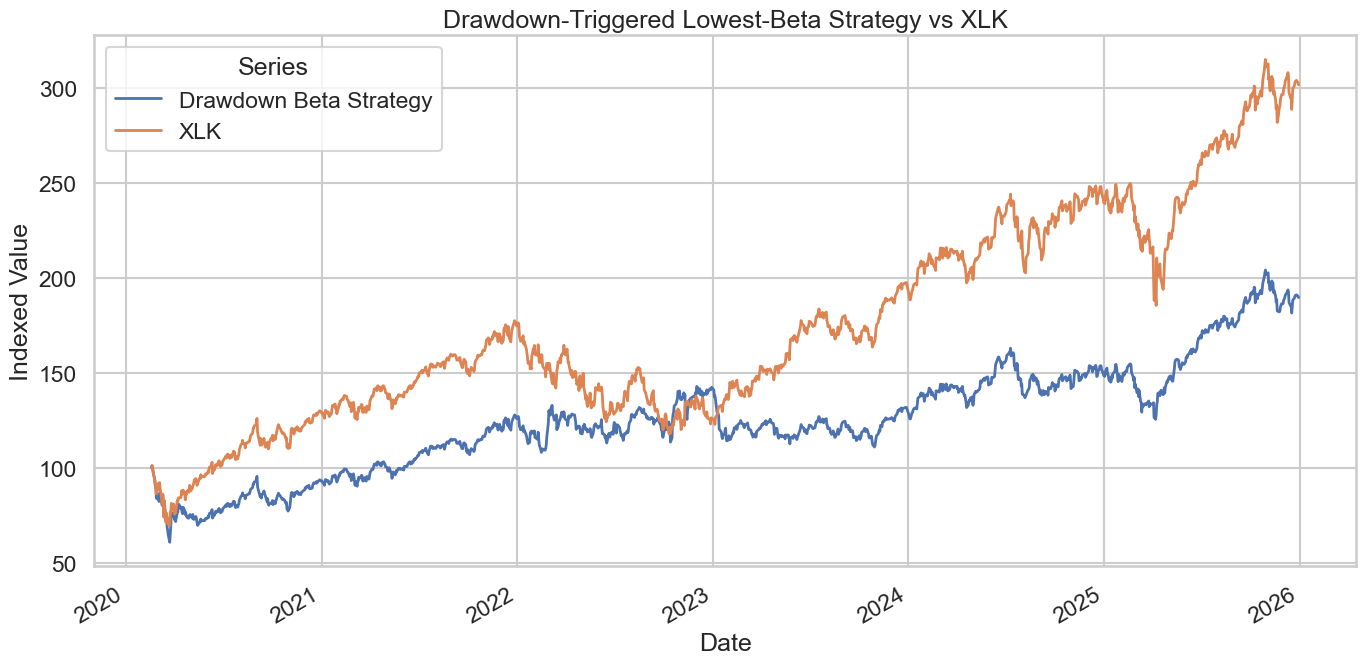

,annual_return,annual_volatility,max_drawdown
Drawdown Beta Strategy,0.1147,0.2568,-0.3975
XLK,0.2065,0.2806,-0.3356


,strategy_return,benchmark_return,signal_date,xlk_drawdown,signal_state,chosen_asset
2020-02-18,-0.0037,-0.0037,2020-02-14,0.0000,Stay XLK,XLK
2020-02-19,0.0119,0.0119,2020-02-18,-0.0037,Stay XLK,XLK
2020-02-20,-0.0104,-0.0104,2020-02-19,0.0000,Stay XLK,XLK
2020-02-21,-0.0224,-0.0224,2020-02-20,-0.0104,Stay XLK,XLK
2020-02-24,-0.0413,-0.0413,2020-02-21,-0.0326,Stay XLK,XLK
2020-02-25,-0.0320,-0.0320,2020-02-24,-0.0726,Stay XLK,XLK
2020-02-26,-0.0166,0.0046,2020-02-25,-0.1022,Defense Switch,NOC
2020-02-27,-0.0539,-0.0539,2020-02-26,-0.0982,Stay XLK,XLK
2020-02-28,-0.0082,0.0076,2020-02-27,-0.1468,Defense Switch,NOC
2020-03-02,0.0217,0.0578,2020-02-28,-0.1403,Defense Switch,NOC


In [22]:
# -----------------------------
# Section 3: Drawdown-triggered strategy charts
# -----------------------------
plot_strategy_comparison(drawdown_strategy_comparison)
plt.title("Drawdown-Triggered Lowest-Beta Strategy vs XLK")
plt.show()

display(drawdown_strategy_summary)
display(drawdown_strategy_log.head(10))


### Chart Captions

Use or adapt these captions in the report:

- **Normalized price performance:** compares cumulative growth from a common starting value so relative outperformance is easy to see.
- **Rolling volatility:** shows how each asset's risk changed over time instead of treating volatility as constant.
- **Correlation matrix:** highlights whether defense names diversified or simply moved with the same market forces as technology.
- **Rolling correlation vs XLK:** shows whether diversification benefits were stable or regime-dependent.
- **Rolling beta vs XLK:** shows how sensitive each defense name was to `XLK` over time, not just whether they moved in the same direction.
- **Return distributions:** reveals tail risk, skewness, and dispersion beyond average returns.
- **Cumulative hedged spreads:** shows whether a defense-vs-tech relative value position produced persistent excess return after accounting for market co-movement.
- **Drawdowns:** show how badly each asset fell from its prior peak and which names preserved capital better.
- **Regime strategy vs XLK:** compares the false-positive same-day version against the corrected lagged version.
- **Drawdown-triggered lowest-beta strategy:** tests whether switching only during `XLK` stress periods improves behavior versus simply holding `XLK`.


In [14]:
# -----------------------------
# Insight generation
# -----------------------------
def generate_key_insights(
    summary_df: pd.DataFrame,
    corr_df: pd.DataFrame,
    hedge_df: pd.DataFrame,
    rolling_corr_df: pd.DataFrame,
    strategy_summary_df: pd.DataFrame,
    drawdown_strategy_summary_df: pd.DataFrame,
) -> List[str]:
    insights = []

    best_return = summary_df["annual_return"].idxmax()
    lowest_risk = summary_df["annual_volatility"].idxmin()
    strongest_defense_link = corr_df.loc[DEFENSE_TICKERS, TECH_TICKER].idxmax()
    weakest_defense_link = corr_df.loc[DEFENSE_TICKERS, TECH_TICKER].idxmin()
    best_hedge_fit = hedge_df["r_squared"].idxmax()
    avg_corr = rolling_corr_df.mean().sort_values(ascending=False)

    insights.append(
        f"{best_return} had the highest annualized return over the sample, while {lowest_risk} had the lowest annualized volatility."
    )
    insights.append(
        f"Among defense names, {strongest_defense_link} moved most closely with {TECH_TICKER}, while {weakest_defense_link} offered the weakest average return correlation to tech."
    )
    insights.append(
        f"{best_hedge_fit} produced the strongest OLS fit against {TECH_TICKER}, making it the cleanest candidate for a simple defense-versus-tech hedge framing."
    )
    insights.append(
        f"Rolling correlations were not constant. The most persistently high average rolling correlation pair was {avg_corr.index[0]}."
    )
    insights.append(
        "A high-level strategy interpretation is to prefer dynamic positioning rather than assuming defense is always a stable hedge against technology."
    )
    if not strategy_summary_df.empty:
        strat_return = strategy_summary_df.loc["Regime Strategy", "annual_return"]
        xlk_return = strategy_summary_df.loc[TECH_TICKER, "annual_return"]
        strat_dd = strategy_summary_df.loc["Regime Strategy", "max_drawdown"]
        xlk_dd = strategy_summary_df.loc[TECH_TICKER, "max_drawdown"]
        insights.append(
            f"The one-day-lagged volatility-regime strategy produced annualized return {strat_return:.2%} versus {xlk_return:.2%} for {TECH_TICKER}, with max drawdown {strat_dd:.2%} versus {xlk_dd:.2%}."
        )
    if not drawdown_strategy_summary_df.empty:
        dd_return = drawdown_strategy_summary_df.loc["Drawdown Beta Strategy", "annual_return"]
        xlk_return_dd = drawdown_strategy_summary_df.loc[TECH_TICKER, "annual_return"]
        dd_drawdown = drawdown_strategy_summary_df.loc["Drawdown Beta Strategy", "max_drawdown"]
        xlk_drawdown = drawdown_strategy_summary_df.loc[TECH_TICKER, "max_drawdown"]
        insights.append(
            f"The drawdown-triggered lowest-beta strategy produced annualized return {dd_return:.2%} versus {xlk_return_dd:.2%} for {TECH_TICKER}, with max drawdown {dd_drawdown:.2%} versus {xlk_drawdown:.2%}."
        )


    return insights


key_insights = generate_key_insights(summary_stats, correlation_matrix, hedge_metrics, rolling_corr_vs_xlk, strategy_summary, drawdown_strategy_summary)

for idx, insight in enumerate(key_insights, start=1):
    print(f"{idx}. {insight}")

print("\nSuggested strategy framing:")
print(
    "If rolling correlation to XLK falls and a defense name keeps lower volatility, that stock becomes more attractive as a diversification sleeve. "
    "If correlation rises and hedge-fit improves, the relationship is more suitable for relative-value or hedged pair-style positioning rather than simple diversification."
)

display(strategy_log.head(10))
display(drawdown_strategy_log.head(10))


NameError: name 'drawdown_strategy_summary' is not defined

In [ ]:
# -----------------------------
# Optional export helpers
# -----------------------------
def export_table(df: pd.DataFrame, file_name: str) -> Path:
    output_path = EXPORT_DIR / file_name
    df.to_csv(output_path)
    return output_path


def export_current_figure(file_name: str) -> Path:
    output_path = EXPORT_DIR / file_name
    plt.gcf().savefig(output_path, dpi=300, bbox_inches="tight")
    return output_path


# Example usage:
# export_table(summary_stats, "summary_stats.csv")
# plot_correlation_matrix(correlation_matrix)
# export_current_figure("correlation_matrix.png")


## Final Reflection Prompts

Use these when writing the report conclusion:

1. Which defense stock looked most independent from XLK over time?
2. Did lower correlation also coincide with lower volatility or better drawdown behavior?
3. Was the defense-vs-tech relationship stable enough for a hedge, or did it change materially across volatility regimes?
4. What would a cautious investor do differently after seeing the rolling metrics instead of only full-period averages?
5. Did the volatility-regime strategy actually improve returns, reduce drawdown, or just add complexity?
6. Which mattered more for the strategy idea: correlation, beta, or drawdown behavior?
